<a href="https://colab.research.google.com/github/ArthY07/Projet-Graphes-Et-Reseaux-L3/blob/main/Feschet_Arthur_Chayrigues_Noah.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
%pip install osmnx
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import random
import time
import math
import requests





## Projet Graphes et Réseaux
# Question 1

On modélise le problème à l'aide d'un graphe orienté valué G=(V, E, W) où V est l'ensemble des adresses (les sommets). On considère aussi que E est l'ensemble des arcs, ici les routes.
On ajoute un arc de poids W(i,j) (représentant le temps de trajet) de i vers j s'il existe une route entre i et j.
L'objectif de trouver l'itinéraire le plus rapide entre le sommet de départ (avec ici i, l'entrepôt) et une adresse d'arrivée (ici j, le client) revient à trouver le plus court chemin entre i et j dans G.


In [ ]:
#Question 2
def find_min(N,pi):

    minimum= 999999999
    for x in N :
        if pi[x] < minimum:
            minimum=pi[x]
            resultat = x

    return resultat

def dijkstra_optimise(G, source, target):
    p = source
    parent = {}
    pi = {}
    noeuds_a_initialiser = list(G.nodes())
    i = 0
    while i < len(noeuds_a_initialiser):
        noeud_actuel = noeuds_a_initialiser[i]
        pi[noeud_actuel] = 9999999
        i += 1

    pi[source] = 0
    Q = [source]

    while Q:
        p = find_min(Q, pi)
        if p == target:
            break
        Q.remove(p)

        neighbors = [key for key in G[p]]
        for x in neighbors:
            #Nous sommes passés d'un multigraph en un graphe orienté simple donc retrait du [0]
            poids = G[p][x].get("travel_time", 1)

            if pi[x] > pi[p] + poids:
                pi[x] = pi[p] + poids
                parent[x] = p
                Q.append(x)

    chemin = [target]
    actuel = target
    while actuel != source:
        actuel = parent[actuel]
        chemin.append(actuel)

    chemin.reverse()
    return chemin, pi[target]

Lancement du benchmark...
Taille 100 terminée.
Taille 300 terminée.
Taille 500 terminée.
Taille 800 terminée.
Taille 1000 terminée.


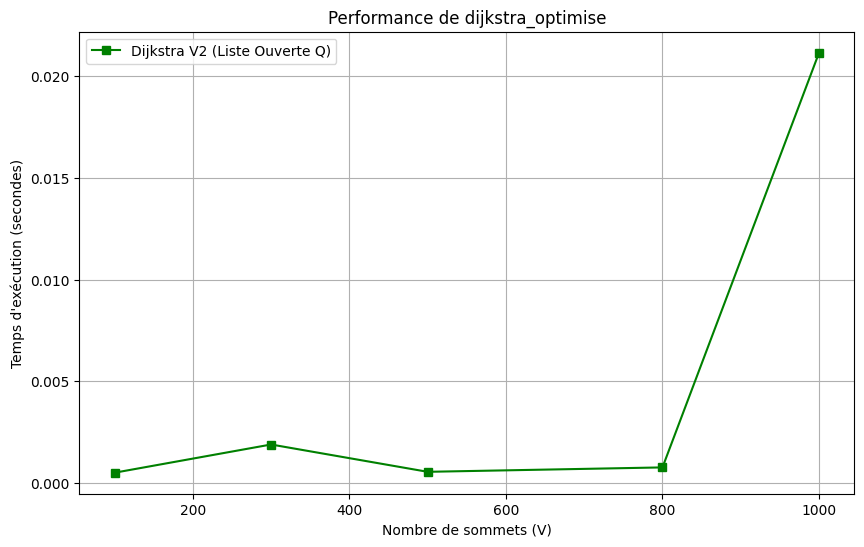

In [ ]:
#Question 3
sizes = [100, 300, 500, 800, 1000]
times_optimise = []

print("Lancement du benchmark...")

for n in sizes:
    #Nous sommes passés d'un multigraph en un graphe orienté simple
    G = nx.gnm_random_graph(n, n * 5, directed=True)

    for u, v, data in G.edges(data=True):
        data['travel_time'] = random.randint(1, 10)

    source = 0
    target = n - 1

    start = time.time()

    dijkstra_optimise(G, source, target)

    times_optimise.append(time.time() - start)
    print(f"Taille {n} terminée.")

plt.figure(figsize=(10, 6))
plt.plot(sizes, times_optimise, label='Dijkstra V2 (Liste Ouverte Q)', marker='s', color='green')
plt.title("Performance de dijkstra_optimise")
plt.xlabel("Nombre de sommets (V)")
plt.ylabel("Temps d'exécution (secondes)")
plt.legend()
plt.grid(True)
plt.show()

# Analyse de performance du graphique question 3
Le graphique montre que le temps de calcul n'est pas régulier et qu'il fait des vagues.
Voici l'explication de ces résultats :Le rôle de la chance (L'aléa)
À chaque test, l'ordinateur crée un nouveau réseau de routes généré aléatoirement. La distance réelle entre le départ et l'arrivée change donc à chaque fois. On observe un impact de la condition "break", l'algorithme s'arrête dès qu'il trouve le client.
A N=800 (le plus haut obsérvé régulièrement), le hasard a probablement placé le client très loin du départ, ainsi l'algorithme a dû fouiller presque toute la carte, ce qui a fait grimper le chronomètre.
A N=1000, le client était sûrement situé très près du départ, l'algorithme a trouvé le chemin tout de suite et s'est arrêté, ce qui explique pourquoi c'est plus rapide malgré une carte plus grande.

On suppose que c'est du à la fonction find_minc car quand l'algorithme est forcé de chercher longtemps (comme au point N=800), la complexité en O(N^2) de cette fonction devient un problème et fait exploser le temps de calcul.

Conclusion de l'analyse : Ce graphique prouve que le temps de calcul dépend plus de la distance entre le départ et l'arrivée (le hasard) que de la taille totale de la carte. Pour obtenir une courbe plus régulière, il faudrait tester chaque taille de carte plusieurs fois et faire une moyenne des résultats pour effacer l'effet du hasard. Selon la loi des grands nombres (vu en cours), plus on augmente le nombre d'essais, plus l'effet de la chance disparaît et la courbe finit par montrer la vraie forme de la complexité.

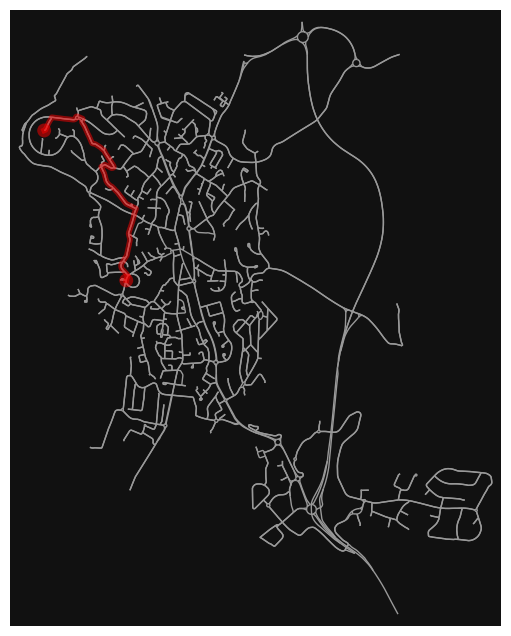

Temps de trajet estimé : 2.978629257305988 minutes
Temps de trajet estimé arrondi: 3.0 minutes


In [ ]:
# Question 4
location = {
    "0": (3.801007, 43.690637),  # Entrepôt
    "1": (3.791705, 43.701633)   # Client
}

# On stocke le graphe d'origine dans G_base (pour l'affichage)
G_base = ox.graph_from_place("Saint-Gély-du-Fesc, France", network_type="drive")
G_base = ox.add_edge_speeds(G_base)
G_base = ox.add_edge_travel_times(G_base)

#Modification 1  : Nous sommes passés d'un multigraph en un graphe orienté simple (avant Mutltigraph, désormais Digraph)
G = nx.DiGraph(G_base)

# On enlève "key" et "keys=True" car G est maintenant un graphe simple
for u, v, data in G.edges(data=True):
    if 'travel_time' in data:
        data['weight'] = data['travel_time']

Entrepôt = ox.distance.nearest_nodes(G, location['0'][0], location['0'][1])
Client   = ox.distance.nearest_nodes(G, location['1'][0], location['1'][1])

chemin, duree = dijkstra_optimise(G, Entrepôt, Client)

# On utilise G_base (le MultiGraph) au lieu de G pour la fonction d'affichage car sinon erreur
fig, ax = ox.plot_graph_route(G_base, chemin, route_color='red', route_linewidth=4, node_size=0)
print(f"Temps de trajet estimé : {duree / 60} minutes")
print(f"Temps de trajet estimé arrondi: {round(duree / 60, 1)} minutes")

# Analyse des résultats sur Saint-Gély-du-Fesc (Question 4)

L'application de notre algorithme sur le réseau réel de Saint-Gély-du-Fesc confirme la validité de notre modèle car le tracé rouge suit parfaitement les routes sans coupure. Le temps de trajet calculé de 3 minutes est tout à fait réaliste car après  vérification il y à environ 2 kilomètres. Cela prouve que notre conversion du graphe d'origine en un graphe orienté simple fonctionne parfaitement sans perdre de précision sur le résultat final.

## Partie 2 Projet

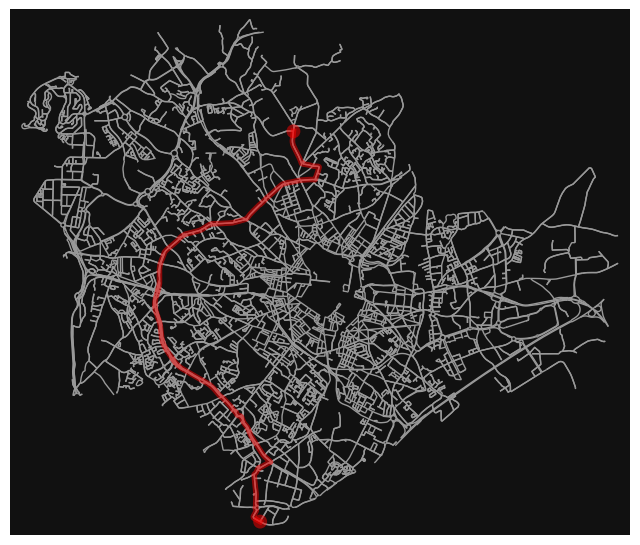

Temps de calcul de l'algorithme : 0.06 secondes
Temps de trajet estimé : 13.9 minutes


In [ ]:
# Projet Graphes et Réseaux
# Question 1 : Trajet depuis l'Amphi 7 (Paul Valéry) jusqu'à la limite Sud de Montpellier (direction Villeneuve-lès-Maguelone, si on fait plus loin cela prend trop de temps).
import time

location = {
    "0": (3.869172, 43.633951),
    "1": (3.846384, 43.544559)
}

G_base = ox.graph_from_place("Montpellier, France", network_type="drive")
G_base = ox.add_edge_speeds(G_base)
G_base = ox.add_edge_travel_times(G_base)

# Nous sommes passés ici aussi à un Digraph
G = nx.DiGraph(G_base)

for u, v, data in G.edges(data=True):
    if 'travel_time' in data:
        data['weight'] = data['travel_time']

Entrepôt = ox.distance.nearest_nodes(G, location['0'][0], location['0'][1])
Client   = ox.distance.nearest_nodes(G, location['1'][0], location['1'][1])

start = time.time()
chemin, duree = dijkstra_optimise(G, Entrepôt, Client)
temps_execution = time.time() - start

fig, ax = ox.plot_graph_route(G_base, chemin, route_color='red', route_linewidth=4, node_size=0)
print(f"Temps de calcul de l'algorithme : {round(temps_execution, 2)} secondes")
print(f"Temps de trajet estimé : {round(duree / 60, 1)} minutes")




# Explication Question 1 Partie 2

Le constat est que Dijkstra est un algorithme « aveugle » : il n'a aucune notion de direction. Il explore tous les sommets de proche en proche à partir de notre point de départ. De ce fait il "s'étale" en explorant tous ses sommets, c'est-à-dire qu'il avance de manière circulaire tout autour de notre point de départ. Il va vérifier à chaque fois chaque sommet le plus proche donc il tourne et s'élargit au fur et à mesure. C'est pourquoi dans un graphe plus dense il y a plus d'intersections et plus de nœuds. L'algorithme de Dijkstra va donc vérifier chaque voisin, même ceux qui partent complètement à l'opposé de la destination parce qu'ils sont proches du départ. Tant qu'un chemin vers le Sud est plus court que le début du trajet vers le Nord (où se trouve notre arrivée), il continuera d'explorer dans la mauvaise direction. Il teste donc chaque rue adjacente même si elle s'éloigne de notre arrivée. C'est ce qui explique pourquoi il traite autant de nœuds inutiles par rapport à A* qui, lui, possède une intuition du chemin pour accéder à l'arrivée grâce à l'heuristique.

Par ailleurs même si l'ordinateur calcule le trajet en seulement 0.07 seconde, il a dû fouiller des milliers d'intersections pour rien. Comme notre destination est au Sud, Dijkstra a aussi exploré tout le Nord et l'Ouest de Montpellier sur la même distance par pur automatisme. On constate donc que l'algorithme explore beaucoup plus de routes que nécessaire (3 fois plus environ), car il cherche partout autour de lui au lieu de viser directement le point d'arrivée. C'est ce gaspillage d'énergie qui finirait par saturer un serveur si on lui demandait des milliers de trajets en même temps.

In [ ]:
def Heuristique(G, source, target):
    x1 = G.nodes[source]['x']
    y1 = G.nodes[source]['y']
    x2 = G.nodes[target]['x']
    y2 = G.nodes[target]['y']
    # Distance euclidienne (en degrés)
    distance_degres = ((x2 - x1) ** 2 + (y2 - y1) ** 2) ** 0.5
    # Conversion en secondes pour être à la même échelle que travel_time
    return (distance_degres * 100000) / 25

def find_min_A(N, f_score):
    minimum = 999999999
    noeud = N[0]
    for x in N:
        if f_score[x] < minimum:
            minimum = f_score[x]
            noeud = x
    return noeud

def A_Etoile(G, source, target):
    p = source
    parent = {}
    pi = {}   #g(n) : coût réel du départ au noeud n
    f_score = {}# f(n) : estimation du coût total (g + h)
    noeuds_a_initialiser = list(G.nodes())
    i = 0
    while i < len(noeuds_a_initialiser):
        noeud_actuel = noeuds_a_initialiser[i]
        pi[noeud_actuel] = 9999999
        f_score[noeud_actuel] = 9999999
        i += 1

    pi[source] = 0
    f_score[source] = Heuristique(G, source, target)
    Q = [source]

    while Q:
        p = find_min_A(Q, f_score)
        if p == target:
            break
        Q.remove(p)

        for x in G.neighbors(p):
            poids = G[p][x].get("weight", 1)

            if pi[x] > pi[p] + poids:
                pi[x] = pi[p] + poids
                parent[x] = p
                f_score[x] = pi[x] + Heuristique(G, x, target)
                if x not in Q:
                    Q.append(x)

    chemin = [target]
    actuel = target
    while actuel != source:
        actuel = parent[actuel]
        chemin.append(actuel)

    chemin.reverse()
    return chemin, pi[target]

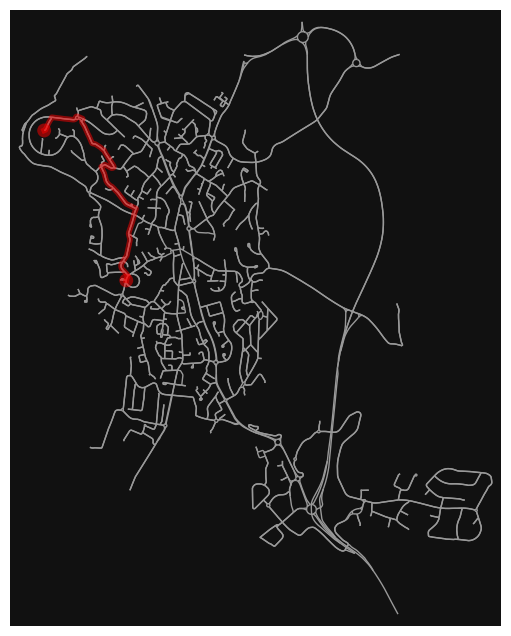

Temps de trajet estimé : 2.978629257305988 minutes
Temps de trajet estimé arrondi: 3.0 minutes


In [ ]:
# Affichage A Etoile
location = {
    "0": (3.801007, 43.690637),  # Entrepôt
    "1": (3.791705, 43.701633)   # Client
}

G_base = ox.graph_from_place("Saint-Gély-du-Fesc, France", network_type="drive")
G_base = ox.add_edge_speeds(G_base)
G_base = ox.add_edge_travel_times(G_base)

# On transforme en DiGraph pour algorithme A_Etoile
G = nx.DiGraph(G_base)

# On prépare les poids (sans le mot "key" car G est maintenant un graphe simple)
for u, v, data in G.edges(data=True):
    if 'travel_time' in data:
        data['weight'] = data['travel_time']

Entrepôt = ox.distance.nearest_nodes(G, location['0'][0], location['0'][1])
Client   = ox.distance.nearest_nodes(G, location['1'][0], location['1'][1])

chemin, duree = A_Etoile(G, Entrepôt, Client)

fig, ax = ox.plot_graph_route(G_base, chemin, route_color='red', route_linewidth=4, node_size=0)
print(f"Temps de trajet estimé : {duree / 60} minutes")
print(f"Temps de trajet estimé arrondi: {round(duree / 60, 1)} minutes")

#Analyse A etoile question 2
C'est tout à fait normal d'obtenir exactement le même résultat car les deux algorithmes ont le même objectif : trouver le chemin le plus court. La seule différence est que A* est plus intelligent, il arrive à la même conclusion que Dijkstra, mais en examinant beaucoup moins d'intersections inutiles grâce à son "intuition" (l'heuristique).

On a récupéré 50 paires sur la Métropole de Montpellier
Lancement du benchmark (cela peut prendre quelques secondes)...
Benchmark terminé


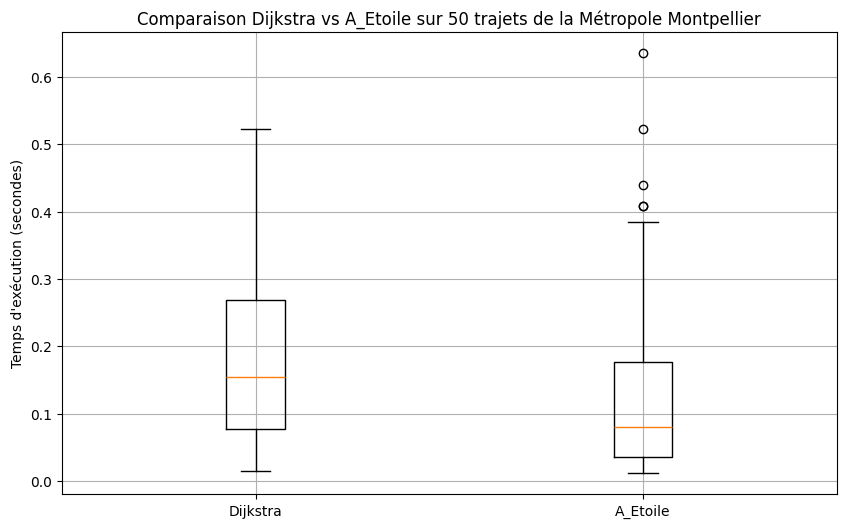

In [ ]:
# Question 3

G_base = ox.graph_from_place("Montpellier Méditerranée Métropole, France", network_type="drive")
G_base = ox.add_edge_speeds(G_base)
G_base = ox.add_edge_travel_times(G_base)

G = nx.DiGraph(G_base)

for u, v, data in G.edges(data=True):
    if 'travel_time' in data:
        data['weight'] = data['travel_time']

nodes = list(G.nodes())
paires = []

# Tirage aléatoire 50 paires de nœuds
for i in range(50):
    depart, arrivee = random.sample(nodes, 2)
    paires.append((depart, arrivee))

print(f"On a récupéré 50 paires sur la Métropole de Montpellier")

times_dijkstra = []
times_astar = []

print("Lancement du benchmark (cela peut prendre quelques secondes)...")

for depart, arrivee in paires:
    # Test Dijkstra
    start_d = time.time()
    dijkstra_optimise(G, depart, arrivee)
    times_dijkstra.append(time.time() - start_d)

    # Test A_Etoile
    start_a = time.time()
    A_Etoile(G, depart, arrivee)
    times_astar.append(time.time() - start_a)

print("Benchmark terminé")

# Affichage graphique
plt.figure(figsize=(10, 6))
plt.boxplot([times_dijkstra, times_astar], tick_labels=['Dijkstra', 'A_Etoile'])
plt.ylabel("Temps d'exécution (secondes)")
plt.title("Comparaison Dijkstra vs A_Etoile sur 50 trajets de la Métropole Montpellier")
plt.grid(True)
plt.show()

#Analyse de performance : Comparaison Dijkstra vs A Etoile (Question 3)

Ce graphique final montre un résultat parfaitement logique : l'algorithme A_Etoile est nettement plus performant que Dijkstra sur un grand réseau urbain.

Pour obtenir cette performance, nous avons dû ajuster notre code sur deux points essentiels car au départ les performances étaient inversées.

D'abord, l'échelle de l'heuristique a été convertie de degrés en secondes pour correspondre au temps de trajet car sans cela, les degrés donnaient une heuristique minime d'environ 0,01 alors qu'une fois convertie, elle est bien plus efficace et donc guide mieux notre algorithme.

Ensuite, nous avons "allégé" la fonction de recherche en calculant cette estimation géographique une seule fois lors de la découverte du noeud, au lieu de la recalculer en boucle.

Maintenant que l'algorithme est optimisé et corrigé, le graphique prouve que A_Etoile est meilleur sur la Métropole de Montpellier. On observe un temps de calcul divisé par deux, avec une ligne médiane pour A Etoile beaucoup plus basse que celle de Dijkstra. De plus, la boîte de A Etoile est plus petite, ce qui montre une grande régularité de l'algorithme qui va droit au but grâce à son intuition. À l'inverse, le temps de calcul de Dijkstra dépend énormément de la chance et explose s'il part dans la mauvaise direction. En conclusion, l'ajout d'une heuristique bien calibrée permet de cibler la recherche au lieu de s'étaler de manière circulaire (Dijkstra), rendant A Etoile indispensable pour une application de livraison à grande échelle sans saturer les serveurs.

#Exercice III : Transition écologique : Les vélos-cargos et l’énergie
##  Question 1
On modèlise le problème à l'aide d'un graphe orienté valué G=(V,E) qui représente le réseau urbain. Nous considérons que V est l'ensemble des sommets qui représente ici l'ensemble des points d'intérêt (entrepôt, points de livraison). De plus chaque sommet de V possède désormais une altitude, on considère que E est l'ensemble des arcs représentant les routes s'il existe une liaison entre un nœud i et un nœud j.
Dans cet nouvel exercice nous ajoutons la valeur des arcs : le poids d'un arc (i,j) représente l'énergie consommée (et non plus le temps ou la distance). Ce poids dépend du dénivelé (côtes) :

En montée : le poids est strictement positif (le vélo consomme de l'énergie).

Sur le plat : le poids est positif (mais faible).

En descente : le poids peut être négatif (le vélo recharge la batterie).

L'objectif du problème est de trouver le chemin minimisant l'énergie totale consommée entre l'entrepôt et le client, ce qui revient à chercher un plus court chemin dans un graphe contenant des poids négatifs.

Note : on considère qu'il est impossible d'avoir un cycle négatif (recharge infinie du vélo), cela nous garantie qu'il existe une solution.


# Question 2

Soit G=(V,E,W) un graphe orienté:
V : l’ensemble des sommets

E : l’ensemble des arcs orientés ici les routes

W : une fonction de poids qui associe à chaque arc un nombre (ici la recharge batterie)

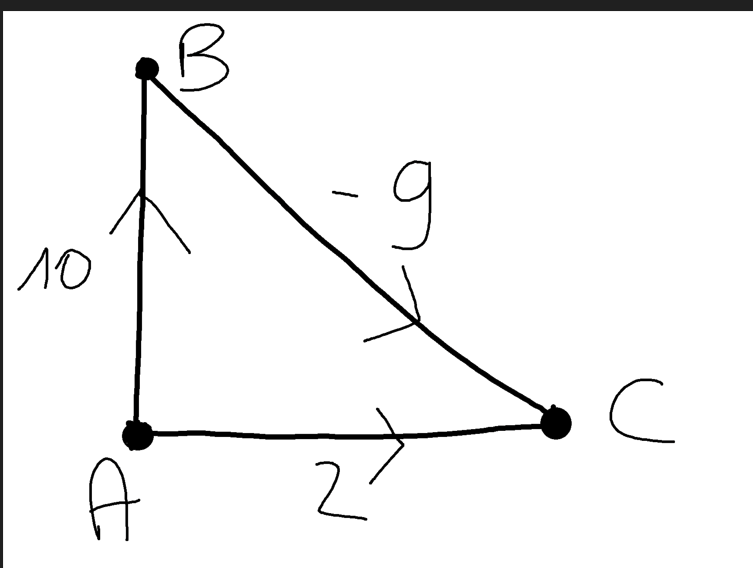

Le mini-graphe dessiné montre pourquoi Dijkstra et A Etoile échouent. Si l'on veut aller de A à C, Dijkstra compare les deux sorties de A : le chemin direct vers C (coût 2) et le chemin vers B (coût 10). Comme il cherche le plus petit chiffre, il valide définitivement le chemin direct A vers C et s'arrête là. Il ignore totalement le passage par B car il considère que 10 est déjà supérieur à 2 et que le coût ne peut qu'augmenter. Pourtant, désormais nous avons des poids négatifs (nouvelles règles physiques) le trajet A vers B (10) suivi de la descente B vers C (-9) donne un coût total de 1. Ce chemin est le meilleur, mais Dijkstra est incapable de le trouver car il "ferme" les noeuds trop vite sans imaginer qu'un poids négatif puisse compenser un coût initial élevé plus loin dans le trajet. Ces algorithmes ne fonctionnent que si les poids sont strictement positifs, c'est pourquoi nous devons utiliser un autre algorithme

In [ ]:
# Question 3 : Algorithme de Bellman-Ford

def Bellman_Ford(G, source, target):
    parent = {}
    pi = {}

    noeuds = list(G.nodes())
    i = 0
    while i < len(noeuds):
        noeud_actuel = noeuds[i]
        pi[noeud_actuel] = 9999999
        parent[noeud_actuel] = None
        i += 1

    pi[source] = 0

    # Au lieu d'utiliser un find_min, on répète l'opération (Nombre de sommets - 1) fois
    nb_sommets = len(noeuds)

    for i in range(nb_sommets - 1):
        changement = False

        for u in noeuds:
          for v in G.neighbors(u):
              poids = G[u][v].get("weight", 1)
              if pi[u] != 9999999 and pi[u] + poids < pi[v]:
                pi[v] = pi[u] + poids
                parent[v] = u
                changement = True

    # Vérification des cycles négatifs
    for u in noeuds:
        for v in G.neighbors(u):
            poids = G[u][v].get("weight", 1)
            if pi[u] != 9999999 and pi[u] + poids < pi[v]:
                print("Le graphe contient un cycle d'énergie infinie (cycle négatif)")
                return [], 9999999

    chemin = [target]
    actuel = target

    while actuel != source:
        actuel = parent[actuel]
        chemin.append(actuel)

    chemin.reverse()

    return chemin, pi[target]

#Question 3 explication algorithme

Cette implémentation utilise l'algorithme de Bellman-Ford, qui est la solution de référence pour les graphes comportant des poids négatifs. Ainsi Bellman-Ford ne choisit pas le meilleur noeud localement, il balaye tout le réseau plusieurs fois. À chaque passage, il met à jour les scores dès qu'une descente permet de compenser une montée passée. Ce système garantit de trouver le trajet le plus économe en énergie, car il accepte un coût initial élevé s'il mène à une grosse recharge plus loin.

#Question 4

Lancement du benchmark...
Taille 50 terminée.
Taille 100 terminée.
Taille 200 terminée.
Taille 300 terminée.
Taille 500 terminée.


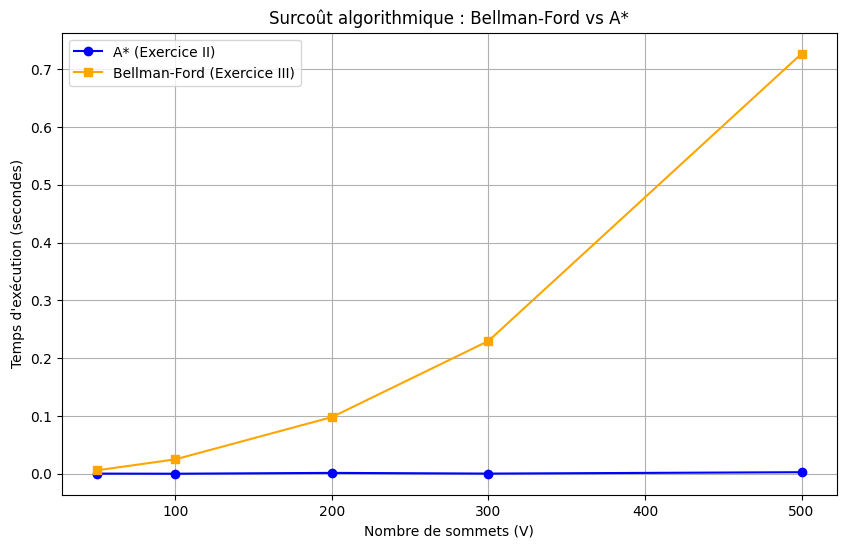

In [ ]:
# Question 4 : Surcoût algorithmique - Bellman-Ford vs A*
import time

sizes = [50, 100, 200, 300, 500]
times_astar    = []
times_bellman  = []

print("Lancement du benchmark...")

for n in sizes:
    G_test = nx.gnm_random_graph(n, n * 4, directed=True)

    # Attributs x/y nécessaires pour l'heuristique de A*
    for noeud, data in G_test.nodes(data=True):
        data['x'] = random.uniform(3.8, 3.95)
        data['y'] = random.uniform(43.55, 43.70)
        data['elevation'] = random.uniform(10, 60)

    # Poids énergétiques (peuvent être négatifs = descente)
    for u, v, data in G_test.edges(data=True):
        dist = random.uniform(50, 500)
        diff = G_test.nodes[v]['elevation'] - G_test.nodes[u]['elevation']
        data['weight'] = dist + (diff * 4) if diff > 0 else dist + (diff * 2)

    source, target = 0, n - 1

    start = time.time()
    A_Etoile(G_test, source, target)
    times_astar.append(time.time() - start)

    start = time.time()
    Bellman_Ford(G_test, source, target)
    times_bellman.append(time.time() - start)

    print(f"Taille {n} terminée.")

plt.figure(figsize=(10, 6))
plt.plot(sizes, times_astar,   label='A* (Exercice II)',          marker='o', color='blue')
plt.plot(sizes, times_bellman, label='Bellman-Ford (Exercice III)', marker='s', color='orange')
plt.title("Surcoût algorithmique : Bellman-Ford vs A*")
plt.xlabel("Nombre de sommets (V)")
plt.ylabel("Temps d'exécution (secondes)")
plt.legend()
plt.grid(True)
plt.show()

# Question 4 : Surcoût algorithmique (Analyse empirique)

Le surcoût algorithmique de Bellman-Ford est massif. Alors que A* ne visite qu'une fraction du graphe
grâce à son heuristique pour atteindre sa cible, Bellman-Ford doit obligatoirement balayer l'intégralité
du réseau à de multiples reprises pour garantir qu'il n'a raté aucune zone de recharge (poids négatif).

D'après notre benchmark empirique, A* répond de manière quasi instantanée quelle que soit la taille
du graphe, en restant proche de 0 seconde même à 500 sommets. En revanche, Bellman-Ford atteint
environ 0.72 seconde à 500 sommets, et la courbe montre une croissance qui s'accélère nettement
entre 200 et 500 sommets. L'analyse montre que Bellman-Ford est empiriquement plusieurs centaines
de fois plus lent que A* sur notre échantillon.

Mathématiquement, on passe d'un algorithme rapide à un algorithme de complexité O(N × E).
À chaque itération, Bellman-Ford parcourt tous les arcs du graphe, et répète cette opération
(N - 1) fois. C'est ce qui explique la forme de la courbe orange : elle ne croît pas linéairement
mais de plus en plus vite au fur et à mesure que N augmente. Avec des dizaines de milliers de
noeuds comme dans la métropole de Montpellier, ce qui prend 0.72 seconde ici se transformerait
rapidement en plusieurs minutes d'attente.

Concernant l'impact métier, utiliser Bellman-Ford pour une flotte entière de vélos-cargos en temps
réel est donc un grand défi. Le gain écologique (optimisation de la batterie par le freinage
régénératif) garantit le meilleur trajet physique, mais ce gain se paie par une consommation de
ressources informatiques très élevée, donc peu rentable à grande échelle.

#Question 5

Trajet Eco-Vélo trouvé ! Énergie estimée : 994 unités.


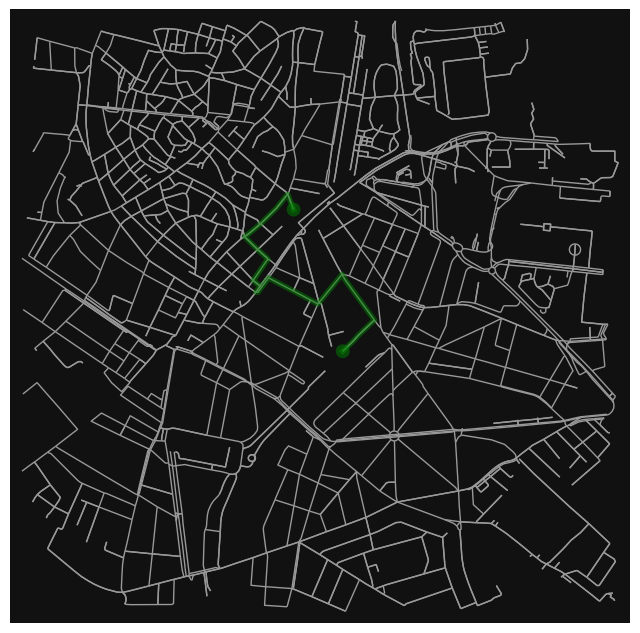

In [36]:

location = {
    "Comedie": (3.879397, 43.608441),
    "Gare": (3.880607, 43.604953)
}

centre_carte = (43.606, 3.880)
G_base = ox.graph_from_point(centre_carte, dist=800, network_type="bike")

nodes = list(G_base.nodes(data=True))
lats = []
lons = []

for noeud, data in nodes:
    lats.append(str(data['y']))
    lons.append(str(data['x']))

altitudes = []

for i in range(0, len(nodes), 40):
    bloc_lats = lats[i:i+40]
    bloc_lons = lons[i:i+40]

    url = f"https://api.open-meteo.com/v1/elevation?latitude={','.join(bloc_lats)}&longitude={','.join(bloc_lons)}"
    reponse = requests.get(url).json()

    if 'elevation' in reponse:
        altitudes.extend(reponse['elevation'])
    else:
        altitudes.extend([20.0] * len(bloc_lats))

for i in range(len(nodes)):
    id_noeud = nodes[i][0]
    if altitudes[i] is not None:
        G_base.nodes[id_noeud]['elevation'] = altitudes[i]
    else:
        G_base.nodes[id_noeud]['elevation'] = 20.0

G = nx.DiGraph(G_base)

for u, v, data in G.edges(data=True):
    dist = data['length']
    diff = G.nodes[v]['elevation'] - G.nodes[u]['elevation']

    if diff > 0:
        data['weight'] = dist + (diff * 4)
    else:
        data['weight'] = dist + (diff * 2)

Depart = ox.distance.nearest_nodes(G, location["Comedie"][0], location["Comedie"][1])
Arrivee = ox.distance.nearest_nodes(G, location["Gare"][0], location["Gare"][1])

chemin, energie = Bellman_Ford(G, Depart, Arrivee)

if chemin:
    print(f"Trajet Eco-Vélo trouvé ! Énergie estimée : {round(energie)} unités.")
    fig, ax = ox.plot_graph_route(G_base, chemin, route_color='green', route_linewidth=4, node_size=0)
else:
    print("Aucun trajet possible.")

## Question 5 : Données réelles (Itinéraire éco-énergie)

### Objectif

Trouver l'itinéraire le plus économe en énergie entre deux points d'un quartier vallonné de Montpellier (Place de la Comédie à Gare Saint-Roch) en utilisant l'algorithme de **Bellman-Ford**, capable de gérer les poids négatifs liés au freinage régénératif des vélos-cargos.


### Construction du graphe routier

Le réseau cyclable est téléchargé dans un rayon de 800 mètres autour du centre du quartier. Ce rayon volontairement limité permet de garder un temps de calcul raisonnable avec Bellman-Ford, dont la complexité est :

$$O(N \times E)$$

Le graphe d'origine (*MultiDiGraph* d’OSMnx) est ensuite converti en graphe orienté simple (*DiGraph*) pour être compatible avec notre implémentation.

### (Open Data)

Pour obtenir un résultat fidèle à la réalité physique du terrain, nous récupérons l'altitude de chaque intersection (nœud) du graphe en interrogeant une API publique et gratuite (**Open-Meteo**).

Afin de respecter les limites techniques de cette API (qui refuse les requêtes trop longues), nous avons mis en place une boucle qui interroge le serveur par petits blocs de 40 coordonnées géographiques.

En cas de donnée manquante ou de refus du serveur sur un bloc, une altitude par défaut est attribuée afin de garantir l'exécution complète de l'algorithme.


### Calcul des poids énergétiques

Le poids de chaque arête est calculé selon le dénivelé réel entre ses deux extrémités :

- **Montée (dénivelé positif)**  
  $$\text{coût} = \text{distance} + 4 \times \text{dénivelé}$$

- **Descente (dénivelé négatif ou nul)**  
  $$\text{coût} = \text{distance} + 2 \times \text{dénivelé}$$

Le coefficient en montée (×4) est volontairement plus élevé qu'en descente (×2) car la récupération d'énergie est toujours partielle physiquement.

En descente forte avec une distance courte, le poids total peut devenir négatif, ce qui justifie l'utilisation de **Bellman-Ford** plutôt que **Dijkstra** ou **A\***.


### Analyse des résultats

Le tracé vert sur la carte montre le chemin minimisant l'énergie totale consommée.

Contrairement à Dijkstra ou A*, Bellman-Ford accepte de prendre un détour plus long en distance si celui-ci passe par des descentes suffisamment fortes pour recharger la batterie et compenser le surcoût initial.

Ce comportement est parfaitement cohérent avec le modèle physique du vélo-cargo à freinage régénératif :

> un trajet passant par une forte descente peut être plus économe en énergie qu'un trajet plat mais plus direct.